# ======================
# Baseline Section (Huiyu)
# ======================


In [22]:
import sys
import os
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    print('MSE:', mean_squared_error(y_test, preds))
    print('R2:', r2_score(y_test, preds))


## Training Baseline Models (Huiyu)

#### In this notebook, I train and compare seveal baseline models using the preprocessed dataset generated from `Preprocessing.py`.

In [23]:
project_root = os.path.abspath("..")
src_path = os.path.join(project_root, "src")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_path not in sys.path:
    sys.path.insert(0, src_path)
print("project_root:", project_root)
print("src_path:", src_path)
# imports
from src.Preprocessing import get_preprocessed_data
from src.validation import evaluate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


project_root: c:\Users\yhy_s\Downloads\california-housing
src_path: c:\Users\yhy_s\Downloads\california-housing\src


In [24]:
X_train, X_test, y_train, y_test = get_preprocessed_data()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Retrieved 68406 rows of data from the database.
Processing 68406 rows of data.
Finished parsing PostalCode.
Finished cyclical encoding CloseDate.
Finished transforming abs(DaysOnMarket).
Finished transforming log(ClosePrice).
Found pre-trained encoder model for Flooring. Returning artifact...
Encoding Flooring...
Encoded Flooring with MultiLabelBinarizer.
Finished de-stacking and encoding Flooring.
Found pre-trained encoder model for Levels. Returning artifact...
Encoding Levels...
Encoded Levels with MultiLabelBinarizer.
Finished de-stacking and encoding Levels.
Finished feature engineering.
Found pre-trained imputer model for YearBuilt. Returning artifact...
Finished imputation for YearBuilt.
Found pre-trained imputer model for BedroomsTotal. Returning artifact...
Finished imputation for BedroomsTotal.
Found pre-trained imputer model for BathroomsTotalInteger. Returning artifact...
Finished imputation for BathroomsTotalInteger.
Finished imputing ['YearBuilt', 'BedroomsTotal', 'Bathro

In [25]:
print("Feature columns:")
print(X_train.columns)

# sanity check: target should not be inside features
assert "ClosePrice" not in X_train.columns

print("\nFeature dtypes:")
print(X_train.dtypes)

# checking if there are any remaining missing values that need to be handled
na_counts = X_train.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
print("\nMissing values per column:")
print(na_counts)

Feature columns:
Index(['Latitude', 'Longitude', 'PostalCode', 'AttachedGarageYN',
       'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'GarageSpaces',
       'LivingArea', 'MainLevelBedrooms', 'NewConstructionYN', 'ParkingTotal',
       'PoolPrivateYN', 'Stories', 'ViewYN', 'YearBuilt', 'LotSizeAcres',
       'LotSizeArea', 'LotSizeSquareFeet', 'AssociationFee', 'CloseDate',
       'DaysOnMarket', 'sin_closed_date', 'cos_closed_date', 'Flooring_Bamboo',
       'Flooring_Brick', 'Flooring_Carpet', 'Flooring_Concrete',
       'Flooring_Laminate', 'Flooring_SeeRemarks', 'Flooring_Stone',
       'Flooring_Tile', 'Flooring_Vinyl', 'Flooring_Wood', 'Levels_MultiSplit',
       'Levels_One', 'Levels_ThreeOrMore', 'Levels_Two'],
      dtype='object')

Feature dtypes:
Latitude                        float64
Longitude                       float64
PostalCode                      float64
AttachedGarageYN                float64
BathroomsTotalInteger           float64
BedroomsTotal      

## Handle missing values

#### As we can see above, some features still comtian missing values after preprocessing.

#### I chose to use median imputation to fill missing values.

In [26]:
# # Used median imputation for missing values.
# imputer = SimpleImputer(strategy="median")

# X_train_imputed = pd.DataFrame(
#     imputer.fit_transform(X_train),
#     columns=X_train.columns,
#     index=X_train.index
# )

# X_test_imputed = pd.DataFrame(
#     imputer.transform(X_test),
#     columns=X_test.columns,
#     index=X_test.index
# )

# print("Missing values after imputation (train):",
#       X_train_imputed.isna().sum().sum())
# print("Missing values after imputation (test):",
#       X_test_imputed.isna().sum().sum())

In [27]:
# Drop raw datetime column; keep cyclical features instead
X_train_model = X_train.drop(columns=["CloseDate"], errors="ignore").copy()
X_test_model = X_test.drop(columns=["CloseDate"], errors="ignore").copy()

print(X_train_model.shape, X_test_model.shape)
print(X_train_model.dtypes.value_counts())

(58668, 37) (8762, 37)
float64    37
Name: count, dtype: int64


#### Define evaluation metrics

#### I evaluate the baseline models using RMSE and R-square.

In [28]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"{name}")
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-"*30)

#### Train baseline models

In this step, I chose the following models as the baseline starting point:
- Linear Regression
- Ridge Regression
- Random Forest
- XGBoost

In [29]:
# Linear Regression baseline
lin_model = LinearRegression()
lin_model.fit(X_train_model, y_train)
lin_pred = lin_model.predict(X_test_model)
evaluate_model("Linear Regression", y_test, lin_pred)

# Ridge Regression baseline
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_model, y_train)
ridge_pred = ridge_model.predict(X_test_model)
evaluate_model("Ridge Regression", y_test, ridge_pred)

# Random Forest baseline
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_model, y_train)
rf_pred = rf_model.predict(X_test_model)
evaluate_model("Random Forest", y_test, rf_pred)

# XGBoost baseline
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)
xgb_model.fit(X_train_model, y_train)
xgb_pred = xgb_model.predict(X_test_model)
evaluate_model("XGBoost", y_test, xgb_pred)

Linear Regression
RMSE: 0.3309222625944167
R2: 0.5540771275854836
------------------------------
Ridge Regression
RMSE: 0.3309182977054904
R2: 0.554087813019901
------------------------------


c:\Users\yhy_s\miniforge3\envs\dsc80\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.842841695049527e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Random Forest
RMSE: 0.17499537901552634
R2: 0.8753015830184618
------------------------------
XGBoost
RMSE: 0.1763392849681706
R2: 0.8733789444175731
------------------------------


#### Baseline results summary

##### As we can see from the results, tree-based models perform much better than linear models.

##### Linear / Ridge models reach around 0.55 R-square. Random Forest and XGBoost reach around 0.87 R-square. This shows that the relationship between features and ClosePrice is highly non-linear.


#### Tuning Random Forest

In [30]:
rf_candidates = [
    {
        "model_name": "RF_baseline_reference",
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "model_name": "RF_more_trees",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "model_name": "RF_shallower_trees",
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "model_name": "RF_regularized_split",
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_split": 10,
        "min_samples_leaf": 4,
    },
    {
        "model_name": "RF_stronger_regularization",
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_split": 10,
        "min_samples_leaf": 4,
    },
]

rf_tuning_results = []
best_rf_model = None
best_rf_result = None
best_r2 = -np.inf

for config in rf_candidates:
    rf_tuned_model = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_split=config["min_samples_split"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    )

    rf_tuned_model.fit(X_train_model, y_train)
    rf_tuned_pred = rf_tuned_model.predict(X_test_model)

    rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_pred))
    r2 = r2_score(y_test, rf_tuned_pred)

    result_row = {
        "model_name": config["model_name"],
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "min_samples_split": config["min_samples_split"],
        "min_samples_leaf": config["min_samples_leaf"],
        "RMSE": rmse,
        "R2": r2
    }

    rf_tuning_results.append(result_row)

    print(f'Model: {config["model_name"]}')
    print(f'Parameters: {config}')
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-" * 50)

    if r2 > best_r2:
        best_r2 = r2
        best_rf_model = rf_tuned_model
        best_rf_result = result_row


rf_results_df = pd.DataFrame(rf_tuning_results)
rf_results_df = rf_results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("Random Forest tuning summary:")
display(rf_results_df)


print("Best Random Forest configuration:")
print(best_rf_result)

best_rf_pred = best_rf_model.predict(X_test_model)

print("\nBest tuned Random Forest performance:")
evaluate_model("Best Tuned Random Forest", y_test, best_rf_pred)

Model: RF_baseline_reference
Parameters: {'model_name': 'RF_baseline_reference', 'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
RMSE: 0.17499537901552636
R2: 0.8753015830184617
--------------------------------------------------
Model: RF_more_trees
Parameters: {'model_name': 'RF_more_trees', 'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
RMSE: 0.1746345867695166
R2: 0.8758152405043896
--------------------------------------------------
Model: RF_shallower_trees
Parameters: {'model_name': 'RF_shallower_trees', 'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1}
RMSE: 0.17669588162971495
R2: 0.8728663155954675
--------------------------------------------------
Model: RF_regularized_split
Parameters: {'model_name': 'RF_regularized_split', 'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4}
RMSE: 0.17671124028384638
R2: 0.8728442133582146
-------

,model_name,n_estimators,max_depth,min_samples_split,min_samples_leaf,RMSE,R2
0,RF_more_trees,300,NaN,2,1,0.174635,0.875815
1,RF_baseline_reference,200,NaN,2,1,0.174995,0.875302
2,RF_shallower_trees,200,20.0,2,1,0.176696,0.872866
3,RF_regularized_split,200,20.0,10,4,0.176711,0.872844
4,RF_stronger_regularization,300,15.0,10,4,0.185340,0.860124


Best Random Forest configuration:
{'model_name': 'RF_more_trees', 'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'RMSE': 0.1746345867695166, 'R2': 0.8758152405043896}

Best tuned Random Forest performance:
Best Tuned Random Forest
RMSE: 0.17463458676951663
R2: 0.8758152405043896
------------------------------


#### Tuning XGBoost

In [31]:
xgb_candidates = [
    {
        "model_name": "XGB_baseline_reference",
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_more_trees",
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_lower_learning_rate",
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_shallower_trees",
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_more_regularized_sampling",
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
    },
]



xgb_tuning_results = []
best_xgb_model = None
best_xgb_result = None
best_xgb_r2 = -np.inf

for config in xgb_candidates:
    xgb_tuned_model = XGBRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        learning_rate=config["learning_rate"],
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"],
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    )

    xgb_tuned_model.fit(X_train_model, y_train)
    xgb_tuned_pred = xgb_tuned_model.predict(X_test_model)

    rmse = np.sqrt(mean_squared_error(y_test, xgb_tuned_pred))
    r2 = r2_score(y_test, xgb_tuned_pred)

    result_row = {
        "model_name": config["model_name"],
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "learning_rate": config["learning_rate"],
        "subsample": config["subsample"],
        "colsample_bytree": config["colsample_bytree"],
        "RMSE": rmse,
        "R2": r2
    }

    xgb_tuning_results.append(result_row)

    print(f'Model: {config["model_name"]}')
    print(f'Parameters: {config}')
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-" * 50)

    if r2 > best_xgb_r2:
        best_xgb_r2 = r2
        best_xgb_model = xgb_tuned_model
        best_xgb_result = result_row



xgb_results_df = pd.DataFrame(xgb_tuning_results)
xgb_results_df = xgb_results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("XGBoost tuning summary:")
display(xgb_results_df)



print("Best XGBoost configuration:")
print(best_xgb_result)

best_xgb_pred = best_xgb_model.predict(X_test_model)

print("\nBest tuned XGBoost performance:")
evaluate_model("Best Tuned XGBoost", y_test, best_xgb_pred)

Model: XGB_baseline_reference
Parameters: {'model_name': 'XGB_baseline_reference', 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE: 0.1763392849681706
R2: 0.8733789444175731
--------------------------------------------------
Model: XGB_more_trees
Parameters: {'model_name': 'XGB_more_trees', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE: 0.17119314088737053
R2: 0.880661520860739
--------------------------------------------------
Model: XGB_lower_learning_rate
Parameters: {'model_name': 'XGB_lower_learning_rate', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE: 0.17897537311530837
R2: 0.8695649431649914
--------------------------------------------------
Model: XGB_shallower_trees
Parameters: {'model_name': 'XGB_shallower_trees', 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsa

,model_name,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,RMSE,R2
0,XGB_more_trees,300,6,0.10,0.8,0.8,0.171193,0.880662
1,XGB_baseline_reference,200,6,0.10,0.8,0.8,0.176339,0.873379
2,XGB_lower_learning_rate,300,6,0.05,0.8,0.8,0.178975,0.869565
3,XGB_shallower_trees,200,4,0.10,0.8,0.8,0.195844,0.843819
4,XGB_more_regularized_sampling,300,4,0.05,0.7,0.7,0.203070,0.832081


Best XGBoost configuration:
{'model_name': 'XGB_more_trees', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'RMSE': 0.17119314088737053, 'R2': 0.880661520860739}

Best tuned XGBoost performance:
Best Tuned XGBoost
RMSE: 0.17119314088737053
R2: 0.880661520860739
------------------------------


#### GridSearchCV for Random Forest

In [32]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train_model, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.8455953431740291


In [33]:
best_rf = rf_grid.best_estimator_
rf_tuned_pred = best_rf.predict(X_test_model)

evaluate_model("Tuned Random Forest", y_test, rf_tuned_pred)

Tuned Random Forest
RMSE: 0.19658918009578083
R2: 0.8426281676296757
------------------------------


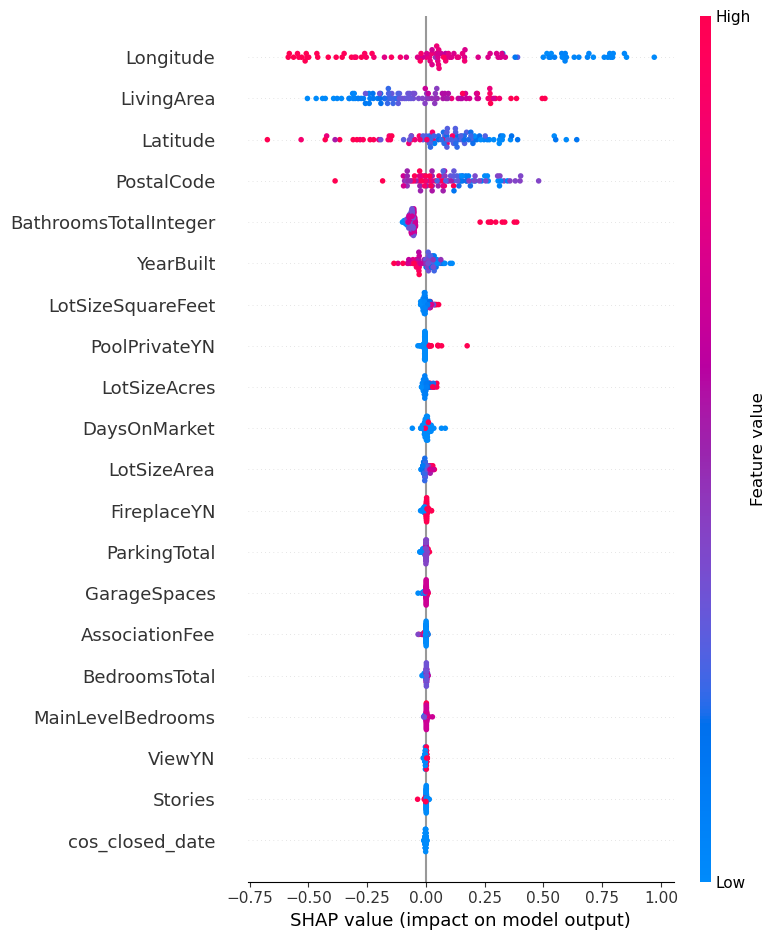

In [36]:
import shap
X_shap = X_test_model.iloc[:100]
explainer = shap.TreeExplainer(rf_model)   
shap_val = explainer.shap_values(X_shap)
shap.summary_plot(shap_val, X_shap)


#### Linear Regression with Continuous Features

In this section, I explore a simpler linear model using only continuous features.

The goal is to evaluate whether a linear relationship between features and target
can achieve competitive performance compared to tree-based models.

If performance is not satisfactory, I will consider engineering additional features.

In [37]:
continuous_cols = [
    'Latitude',
    'Longitude',
    'BathroomsTotalInteger',
    'BedroomsTotal',
    'GarageSpaces',
    'LivingArea',
    'MainLevelBedrooms',
    'ParkingTotal',
    'Stories',
    'YearBuilt',
    'LotSizeAcres',
    'LotSizeArea',
    'LotSizeSquareFeet',
    'AssociationFee',
    'DaysOnMarket',
    'sin_closed_date'
]

X_train_cont = X_train[continuous_cols]
X_test_cont = X_test[continuous_cols]

lr = LinearRegression()
lr.fit(X_train_cont, y_train)

y_pred = lr.predict(X_test_cont)

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("RMSE (log scale):", rmse)
print("R^2:", r2)

RMSE (log scale): 0.3363890731064819
R^2: 0.5392222081089535


c:\Users\yhy_s\miniforge3\envs\dsc80\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


#### Engineer new features

In [38]:
X_train_cont = X_train_cont.copy()
X_test_cont = X_test_cont.copy()

# Feature engineering
X_train_cont['HouseAge'] = 2026 - X_train_cont['YearBuilt']
X_test_cont['HouseAge'] = 2026 - X_test_cont['YearBuilt']

X_train_cont['AreaPerRoom'] = X_train_cont['LivingArea'] / (X_train_cont['BedroomsTotal'] + 1)
X_test_cont['AreaPerRoom'] = X_test_cont['LivingArea'] / (X_test_cont['BedroomsTotal'] + 1)

X_train_cont['log_LivingArea'] = np.log1p(X_train_cont['LivingArea'])
X_test_cont['log_LivingArea'] = np.log1p(X_test_cont['LivingArea'])

X_train_cont['LivingArea_per_Lot'] = X_train_cont['LivingArea'] / (X_train_cont['LotSizeSquareFeet'] + 1)
X_test_cont['LivingArea_per_Lot'] = X_test_cont['LivingArea'] / (X_test_cont['LotSizeSquareFeet'] + 1)

# Clean after feature engineering
X_train_cont = X_train_cont.replace([np.inf, -np.inf], np.nan)
X_test_cont = X_test_cont.replace([np.inf, -np.inf], np.nan)

X_train_cont = X_train_cont.fillna(X_train_cont.median())
X_test_cont = X_test_cont.fillna(X_train_cont.median())

# Refit model
lr_new = LinearRegression()
lr_new.fit(X_train_cont, y_train)

y_pred_new = lr_new.predict(X_test_cont)

rmse_new = mean_squared_error(y_test, y_pred_new, squared=False)
r2_new = r2_score(y_test, y_pred_new)

print("New RMSE:", rmse_new)
print("New R^2:", r2_new)

New RMSE: 0.334798601194815
New R^2: 0.5435690891478884


c:\Users\yhy_s\miniforge3\envs\dsc80\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [39]:
print("Baseline RMSE:", rmse)
print("Baseline R^2:", r2)
print("New RMSE:", rmse_new)
print("New R^2:", r2_new)

Baseline RMSE: 0.3363890731064819
Baseline R^2: 0.5392222081089535
New RMSE: 0.334798601194815
New R^2: 0.5435690891478884


In [1]:
os.chdir("..")
sys.path.append(os.getcwd())


In [3]:
X_train, X_test, y_train, y_test = get_preprocessed_data(output_as='random_split')

print(X_train.shape)
print(X_test.shape)

Retrieved 74635 rows of data from the database.
Processing 74635 rows of data.
Finished parsing PostalCode.
Finished cyclical encoding CloseDate.
Finished transforming abs(DaysOnMarket).
Finished transforming log(ClosePrice).
Found pre-trained encoder model for Flooring. Returning artifact...
Encoding Flooring...
Encoded Flooring with MultiLabelBinarizer.
Finished de-stacking and encoding Flooring.
Found pre-trained encoder model for Levels. Returning artifact...
Encoding Levels...
Encoded Levels with MultiLabelBinarizer.
Finished de-stacking and encoding Levels.
Finished feature engineering.
Found pre-trained imputer model for YearBuilt. Returning artifact...
Finished imputation for YearBuilt.
Found pre-trained imputer model for BedroomsTotal. Returning artifact...
Finished imputation for BedroomsTotal.
Found pre-trained imputer model for BathroomsTotalInteger. Returning artifact...
Finished imputation for BathroomsTotalInteger.
Finished imputing ['YearBuilt', 'BedroomsTotal', 'Bathro

In [4]:
X_train.dtypes

Latitude                        float64
Longitude                       float64
PostalCode                      float64
AttachedGarageYN                float64
BathroomsTotalInteger           float64
BedroomsTotal                   float64
FireplaceYN                     float64
GarageSpaces                    float64
LivingArea                      float64
MainLevelBedrooms               float64
NewConstructionYN               float64
ParkingTotal                    float64
PoolPrivateYN                   float64
Stories                         float64
ViewYN                          float64
YearBuilt                       float64
LotSizeAcres                    float64
LotSizeArea                     float64
LotSizeSquareFeet               float64
AssociationFee                  float64
CloseDate                datetime64[us]
DaysOnMarket                    float64
sin_closed_date                 float64
cos_closed_date                 float64
Flooring_Bamboo                 float64


In [5]:
X_train

,Latitude,Longitude,PostalCode,AttachedGarageYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,GarageSpaces,LivingArea,MainLevelBedrooms,...,Flooring_Laminate,Flooring_SeeRemarks,Flooring_Stone,Flooring_Tile,Flooring_Vinyl,Flooring_Wood,Levels_MultiSplit,Levels_One,Levels_ThreeOrMore,Levels_Two
54824,34.090105,-118.249073,90026.0,0.0,3.0,2.0,0.0,1.0,1256.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
51576,36.597097,-121.863551,93940.0,1.0,2.0,3.0,0.0,2.0,1320.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
58279,34.480540,-117.354676,92392.0,1.0,2.0,3.0,1.0,2.0,1860.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
54912,33.223016,-117.355580,92058.0,1.0,3.0,5.0,1.0,3.0,2940.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
50837,33.969631,-117.466725,92509.0,1.0,3.0,3.0,0.0,2.0,1583.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37202,33.707484,-117.788149,92606.0,1.0,3.0,4.0,1.0,2.0,2268.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6266,34.092496,-117.412774,92335.0,1.0,2.0,3.0,1.0,2.0,1260.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
54895,32.777117,-117.189609,92110.0,1.0,2.0,3.0,0.0,2.0,1298.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,34.074362,-117.731794,91767.0,1.0,2.0,3.0,1.0,2.0,1730.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [6]:
X_train["YearBuilt"]

54824    1930.0
51576    2007.0
58279    1990.0
54912    2004.0
50837    2025.0
          ...  
37202    1974.0
6266     1956.0
54895    1958.0
860      1963.0
15802    2025.0
Name: YearBuilt, Length: 59699, dtype: float64

# ======================
# Model Tuning Section (Jenny)
# ======================


In [7]:
X_train["LivingArea"]

54824    1256.0
51576    1320.0
58279    1860.0
54912    2940.0
50837    1583.0
          ...  
37202    2268.0
6266     1260.0
54895    1298.0
860      1730.0
15802    2537.0
Name: LivingArea, Length: 59699, dtype: float64

In [8]:
X_train["PostalCode"]

54824    90026.0
51576    93940.0
58279    92392.0
54912    92058.0
50837    92509.0
          ...   
37202    92606.0
6266     92335.0
54895    92110.0
860      91767.0
15802    92571.0
Name: PostalCode, Length: 59699, dtype: float64

In [9]:
X_train["BedroomsTotal"]

54824    2.0
51576    3.0
58279    3.0
54912    5.0
50837    3.0
        ... 
37202    4.0
6266     3.0
54895    3.0
860      3.0
15802    5.0
Name: BedroomsTotal, Length: 59699, dtype: float64

In [10]:
X_train["BathroomsTotalInteger"]

54824    3.0
51576    2.0
58279    2.0
54912    3.0
50837    3.0
        ... 
37202    3.0
6266     2.0
54895    2.0
860      2.0
15802    3.0
Name: BathroomsTotalInteger, Length: 59699, dtype: float64

Drop CloseDate and PostalCode to train the models.

In [4]:
X_train_cp = X_train.copy()
X_test_cp = X_test.copy()

In [5]:
drop_cols = ["CloseDate", "PostalCode"]

X_train_cp = X_train_cp.drop(columns=drop_cols)
X_test_cp  = X_test_cp.drop(columns=drop_cols)

In [6]:
X_train_new = X_train_cp.copy()
X_test_new = X_test_cp.copy()
X_train_new["bed_bath_ratio"] = X_train_new["BedroomsTotal"] / (X_train_new["BathroomsTotalInteger"] + 1e-6)
X_test_new["bed_bath_ratio"] = X_test_new["BedroomsTotal"] / (X_test_new["BathroomsTotalInteger"] + 1e-6)

# X_train_new["property_age"] = X_train_new["CloseDate"].dt.year - X_train_new["YearBuilt"]
# X_test_new["property_age"] = X_test_new["CloseDate"].dt.year - X_test_new["YearBuilt"]

# Linear Regression

In [9]:
lm = LinearRegression()
lm.fit(X_train_cp, y_train)

y_pred = lm.predict(X_test_cp)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.3319077446696973
R2: 0.5378106106755246


Using X_train_new and X_test_new:

In [10]:
lm = LinearRegression()
lm.fit(X_train_new, y_train)

y_pred = lm.predict(X_test_new)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.33190832263180103
R2: 0.5378090010223082


# Random Forest

In [14]:
X_train_rf = X_train.copy().drop(columns="CloseDate")
X_test_rf = X_test.copy().drop(columns="CloseDate")

In [29]:
for depth in [15, 20, 30]:
    for n in [100, 200, 300]:

        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train_rf, y_train)
        y_pred = rf.predict(X_test_rf)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        train_r2 = rf.score(X_train_rf, y_train)

        print(f"n={n}, depth={depth}")
        print("Train R2:", train_r2)
        print("Test  R2:", r2)
        print("RMSE:", rmse)
        print("---------")

n=100, depth=15
Train R2: 0.9551304927622009
Test  R2: 0.8564320320193657
RMSE: 0.18498485673159337
---------
n=200, depth=15
Train R2: 0.9552748191611622
Test  R2: 0.8601795498358732
RMSE: 0.18255458657061352
---------
n=300, depth=15
Train R2: 0.9553194127264619
Test  R2: 0.85979924529321
RMSE: 0.18280268759424204
---------
n=100, depth=20
Train R2: 0.9785004042100913
Test  R2: 0.8711079948269749
RMSE: 0.17527516749888927
---------
n=200, depth=20
Train R2: 0.978527049425082
Test  R2: 0.8730953906312995
RMSE: 0.17391862734821265
---------
n=300, depth=20
Train R2: 0.978653603962624
Test  R2: 0.8727543001550937
RMSE: 0.17415219719340472
---------
n=100, depth=30
Train R2: 0.9833630556146091
Test  R2: 0.8718255703302366
RMSE: 0.17478658518390555
---------
n=200, depth=30
Train R2: 0.9834303499392895
Test  R2: 0.8747986389274267
RMSE: 0.1727475616003697
---------
n=300, depth=30
Train R2: 0.9836646354649555
Test  R2: 0.8748336464909401
RMSE: 0.17272340893151972
---------


     n  depth    RMSE  Train_R2  Test_R2     Gap
0  100     15  0.1850    0.9551   0.8564  0.0987
1  200     15  0.1826    0.9553   0.8602  0.0951
2  300     15  0.1828    0.9553   0.8598  0.0955
3  100     20  0.1753    0.9785   0.8711  0.1074
4  200     20  0.1739    0.9785   0.8731  0.1054
5  300     20  0.1742    0.9787   0.8728  0.1059
6  100     30  0.1748    0.9834   0.8718  0.1115
7  200     30  0.1727    0.9834   0.8748  0.1086
8  300     30  0.1727    0.9837   0.8748  0.1088


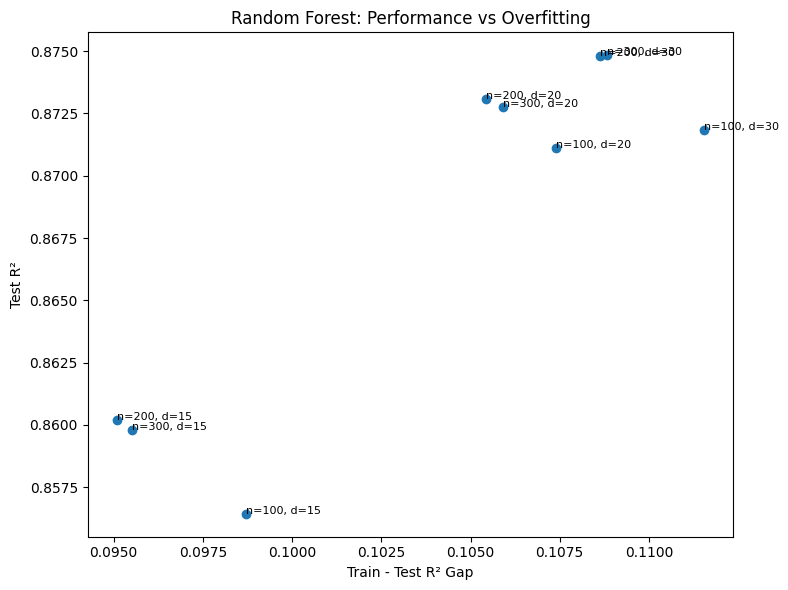

In [22]:
import matplotlib.pyplot as plt
rows = [
    {"n": 100, "depth": 15, "RMSE": 0.18498485673159334, "Train_R2": 0.9551304927622009, "Test_R2": 0.8564320320193657},
    {"n": 200, "depth": 15, "RMSE": 0.18255458657061352, "Train_R2": 0.9552748191611622, "Test_R2": 0.8601795498358731},
    {"n": 300, "depth": 15, "RMSE": 0.18280268759424204, "Train_R2": 0.9553194127264619, "Test_R2": 0.85979924529321},
    {"n": 100, "depth": 20, "RMSE": 0.17527516749888927, "Train_R2": 0.9785004042100913, "Test_R2": 0.8711079948269749},
    {"n": 200, "depth": 20, "RMSE": 0.17391862734821267, "Train_R2": 0.978527049425082, "Test_R2": 0.8730953906312995},
    {"n": 300, "depth": 20, "RMSE": 0.1741521971934047, "Train_R2": 0.978653603962624, "Test_R2": 0.8727543001550937},
    {"n": 100, "depth": 30, "RMSE": 0.17478658518390552, "Train_R2": 0.9833630556146091, "Test_R2": 0.8718255703302367},
    {"n": 200, "depth": 30, "RMSE": 0.1727475616003697, "Train_R2": 0.9834303499392895, "Test_R2": 0.8747986389274267},
    {"n": 300, "depth": 30, "RMSE": 0.17272340893151966, "Train_R2": 0.9836646354649555, "Test_R2": 0.8748336464909401},
]
df = pd.DataFrame(rows)
# Create the overfitting gap
df["Gap"] = df["Train_R2"] - df["Test_R2"]
# Print table
print(df.round(4))
# Scatter plot: overfitting vs performance
plt.figure(figsize=(8, 6))
plt.scatter(df["Gap"], df["Test_R2"])
for _, row in df.iterrows():
    plt.annotate(
        f"n={int(row['n'])}, d={int(row['depth'])}",
        (row["Gap"], row["Test_R2"]),
        fontsize=8
    )
plt.xlabel("Train - Test R² Gap")
plt.ylabel("Test R²")
plt.title("Random Forest: Performance vs Overfitting")
plt.tight_layout()
plt.show()


After tuning n_estimators and max_depth, the best Random Forest uses 300 trees and depth 30. $R^2$ = 0.8748. However, considering the overfitting, 200 trees and depth 20 could be a better one with $R^2$ = 0.873.

# XGBoost

In [23]:
X_train_xgb = X_train.copy().drop(columns="CloseDate")
X_test_xgb = X_test.copy().drop(columns="CloseDate")

In [24]:
import xgboost as xgb


Baseline mdoel:

In [25]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_xgb, y_train)
y_pred = xgb_model.predict(X_test_xgb)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.17728224382062274
R2: 0.868139208545286


In [27]:
for depth in [3, 4, 6, 8]:
    for lr in [0.03, 0.05, 0.1]:
        for n in [200, 300, 500]:
            model = xgb.XGBRegressor(
                n_estimators=n,
                max_depth=depth,
                learning_rate=lr,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_train_xgb, y_train)
            y_pred = model.predict(X_test_xgb)
            y_train_pred = model.predict(X_train_xgb)

            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            train_r2 = r2_score(y_train, y_train_pred)

            gap = train_r2 - r2

            print(f"n={n}, depth={depth}, lr={lr}")
            print("Train R2:", train_r2)
            print("Test  R2:", r2)
            print("RMSE:", rmse)
            print("Gap:", gap)
            print("---------")

n=200, depth=3, lr=0.03
Train R2: 0.7817411410681857
Test  R2: 0.7493477763314803
RMSE: 0.24442362553008845
Gap: 0.0323933647367054
---------
n=300, depth=3, lr=0.03
Train R2: 0.8098235897177445
Test  R2: 0.7748801696612087
RMSE: 0.23164038451333904
Gap: 0.034943420056535834
---------
n=500, depth=3, lr=0.03
Train R2: 0.8329531134276316
Test  R2: 0.7999524105965726
RMSE: 0.21836049091198187
Gap: 0.03300070283105894
---------
n=200, depth=3, lr=0.05
Train R2: 0.8157950848650447
Test  R2: 0.7819382849663976
RMSE: 0.22798019064929576
Gap: 0.033856799898647094
---------
n=300, depth=3, lr=0.05
Train R2: 0.8333136086713453
Test  R2: 0.8013073100483141
RMSE: 0.2176197692553586
Gap: 0.03200629862303117
---------
n=500, depth=3, lr=0.05
Train R2: 0.8545466836508856
Test  R2: 0.8251697594760268
RMSE: 0.20413415636519516
Gap: 0.02937692417485882
---------
n=200, depth=3, lr=0.1
Train R2: 0.8471390924566563
Test  R2: 0.8168429171817924
RMSE: 0.20893887870567782
Gap: 0.030296175274863946
---------

      n  depth    lr  Train_R2  Test_R2     Gap
0   200      3  0.03    0.7817   0.7493  0.0324
1   300      3  0.03    0.8098   0.7749  0.0349
2   500      3  0.03    0.8330   0.8000  0.0330
3   200      3  0.05    0.8158   0.7819  0.0339
4   300      3  0.05    0.8333   0.8013  0.0320
5   500      3  0.05    0.8545   0.8252  0.0293
6   200      3  0.10    0.8471   0.8168  0.0303
7   300      3  0.10    0.8615   0.8329  0.0286
8   500      3  0.10    0.8785   0.8520  0.0265
9   200      4  0.05    0.8465   0.8132  0.0333
10  300      4  0.05    0.8629   0.8312  0.0317
11  500      4  0.05    0.8831   0.8533  0.0298
12  200      6  0.05    0.8937   0.8546  0.0391
13  300      6  0.05    0.9107   0.8681  0.0426
14  500      6  0.05    0.9300   0.8810  0.0490
15  200      8  0.05    0.9376   0.8794  0.0582
16  300      8  0.05    0.9512   0.8867  0.0645
17  500      8  0.05    0.9658   0.8926  0.0732


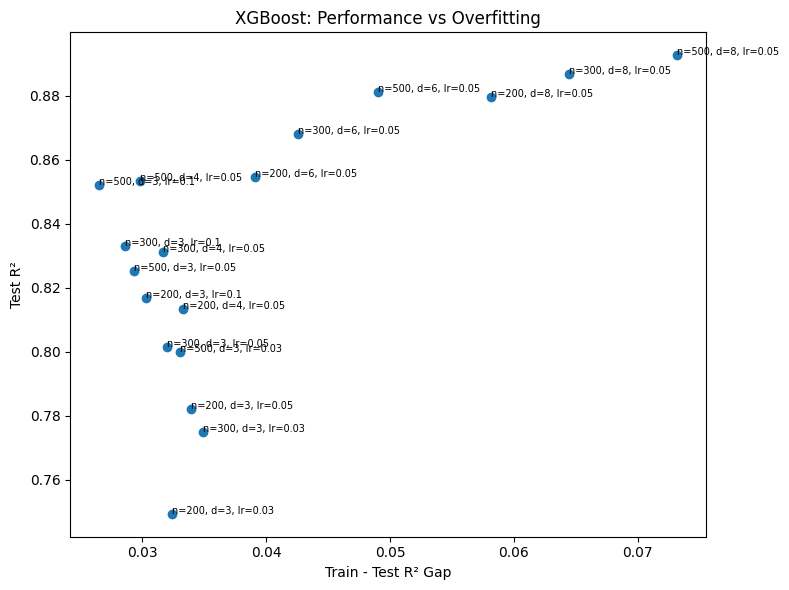

In [30]:
rows = [
{"n":200,"depth":3,"lr":0.03,"Train_R2":0.7817,"Test_R2":0.7493},
{"n":300,"depth":3,"lr":0.03,"Train_R2":0.8098,"Test_R2":0.7749},
{"n":500,"depth":3,"lr":0.03,"Train_R2":0.8330,"Test_R2":0.8000},

{"n":200,"depth":3,"lr":0.05,"Train_R2":0.8158,"Test_R2":0.7819},
{"n":300,"depth":3,"lr":0.05,"Train_R2":0.8333,"Test_R2":0.8013},
{"n":500,"depth":3,"lr":0.05,"Train_R2":0.8545,"Test_R2":0.8252},

{"n":200,"depth":3,"lr":0.1,"Train_R2":0.8471,"Test_R2":0.8168},
{"n":300,"depth":3,"lr":0.1,"Train_R2":0.8615,"Test_R2":0.8329},
{"n":500,"depth":3,"lr":0.1,"Train_R2":0.8785,"Test_R2":0.8520},

{"n":200,"depth":4,"lr":0.05,"Train_R2":0.8465,"Test_R2":0.8132},
{"n":300,"depth":4,"lr":0.05,"Train_R2":0.8629,"Test_R2":0.8312},
{"n":500,"depth":4,"lr":0.05,"Train_R2":0.8831,"Test_R2":0.8533},

{"n":200,"depth":6,"lr":0.05,"Train_R2":0.8937,"Test_R2":0.8546},
{"n":300,"depth":6,"lr":0.05,"Train_R2":0.9107,"Test_R2":0.8681},
{"n":500,"depth":6,"lr":0.05,"Train_R2":0.9300,"Test_R2":0.8810},

{"n":200,"depth":8,"lr":0.05,"Train_R2":0.9376,"Test_R2":0.8794},
{"n":300,"depth":8,"lr":0.05,"Train_R2":0.9512,"Test_R2":0.8867},
{"n":500,"depth":8,"lr":0.05,"Train_R2":0.9658,"Test_R2":0.8926},
]

df = pd.DataFrame(rows)

# gap
df["Gap"] = df["Train_R2"] - df["Test_R2"]

print(df.round(4))

plt.figure(figsize=(8,6))
plt.scatter(df["Gap"], df["Test_R2"])

for _, row in df.iterrows():
    plt.annotate(
        f"n={int(row['n'])}, d={int(row['depth'])}, lr={row['lr']}",
        (row["Gap"], row["Test_R2"]),
        fontsize=7
    )

plt.xlabel("Train - Test R² Gap")
plt.ylabel("Test R²")
plt.title("XGBoost: Performance vs Overfitting")

plt.tight_layout()
plt.show()

The gap is actually lower than what rf does. After tuning, XGBoost outperforms Random Forest. The best model could be depth=8, 500 trees, and learning rate 0.05 with $R^2$ = 0.89.

# SHAP Analysis

In [32]:
best_xgb = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
best_xgb.fit(X_train_xgb, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [34]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, The experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:CloseDate: datetime64[us]

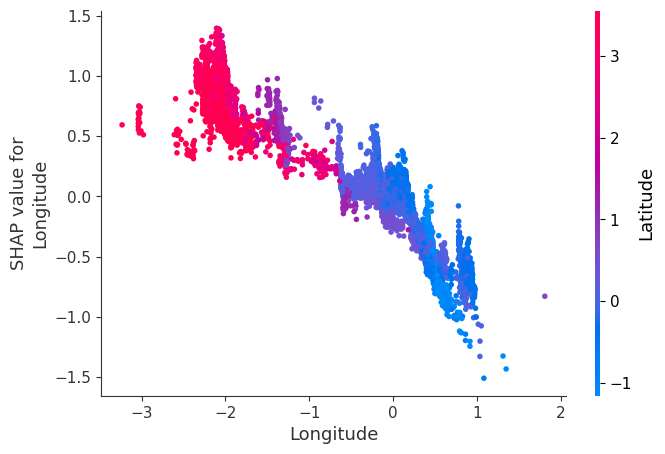

In [16]:
shap.dependence_plot("Longitude", shap_values, X_test)

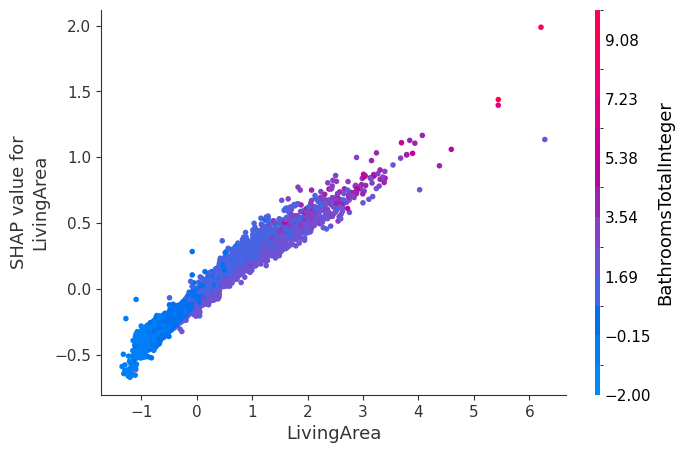

In [17]:
shap.dependence_plot("LivingArea", shap_values, X_test)

In [2]:
from unittest.mock import inplace
from statsmodels.graphics.gofplots import qqplot
X_train, X_test, y_train, y_test = get_preprocessed_data(output_as='random_split')


In [3]:
X_train.head()

,Latitude,Longitude,PostalCode,AttachedGarageYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,GarageSpaces,LivingArea,MainLevelBedrooms,...,Flooring_Vinyl,Flooring_Laminate,Flooring_SeeRemarks,Flooring_Wood,Flooring_Brick,Flooring_Bamboo,Levels_ThreeOrMore,Levels_Two,Levels_One,Levels_MultiSplit
38274,-0.321713,0.118533,0.230263,0,0.0,1.0,0,0.0,-0.016268,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
13971,-0.420112,0.191335,0.140550,0,1.0,1.0,0,0.0,0.348325,-2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5891,-0.439796,0.063116,0.160287,0,2.0,0.0,0,0.0,1.378947,-3.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
36023,-0.387666,0.908424,-0.084928,0,0.0,0.0,0,0.0,-0.430622,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75410,-0.905605,0.477600,-0.218900,0,1.0,0.0,0,0.0,0.056459,-3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0


In [4]:
cols_with_na = []
for col in X_train.columns:
    na_count = X_train[col].isna().sum()
    print(f'{col}: {na_count} NAs')
    if na_count < 100:
        cols_with_na.append(col)



Latitude: 0 NAs
Longitude: 0 NAs
PostalCode: 0 NAs
AttachedGarageYN: 0 NAs
BathroomsTotalInteger: 0 NAs
BedroomsTotal: 0 NAs
FireplaceYN: 0 NAs
GarageSpaces: 0 NAs
LivingArea: 0 NAs
MainLevelBedrooms: 0 NAs
NewConstructionYN: 0 NAs
ParkingTotal: 0 NAs
PoolPrivateYN: 0 NAs
Stories: 0 NAs
ViewYN: 0 NAs
YearBuilt: 0 NAs
LotSizeAcres: 0 NAs
LotSizeArea: 0 NAs
LotSizeSquareFeet: 0 NAs
AssociationFee: 0 NAs
DaysOnMarket: 0 NAs
sin_closed_date: 0 NAs
Flooring_Concrete: 0 NAs
Flooring_Tile: 0 NAs
Flooring_Stone: 0 NAs
Flooring_Carpet: 0 NAs
Flooring_Vinyl: 0 NAs
Flooring_Laminate: 0 NAs
Flooring_SeeRemarks: 0 NAs
Flooring_Wood: 0 NAs
Flooring_Brick: 0 NAs
Flooring_Bamboo: 0 NAs
Levels_ThreeOrMore: 0 NAs
Levels_Two: 0 NAs
Levels_One: 0 NAs
Levels_MultiSplit: 0 NAs


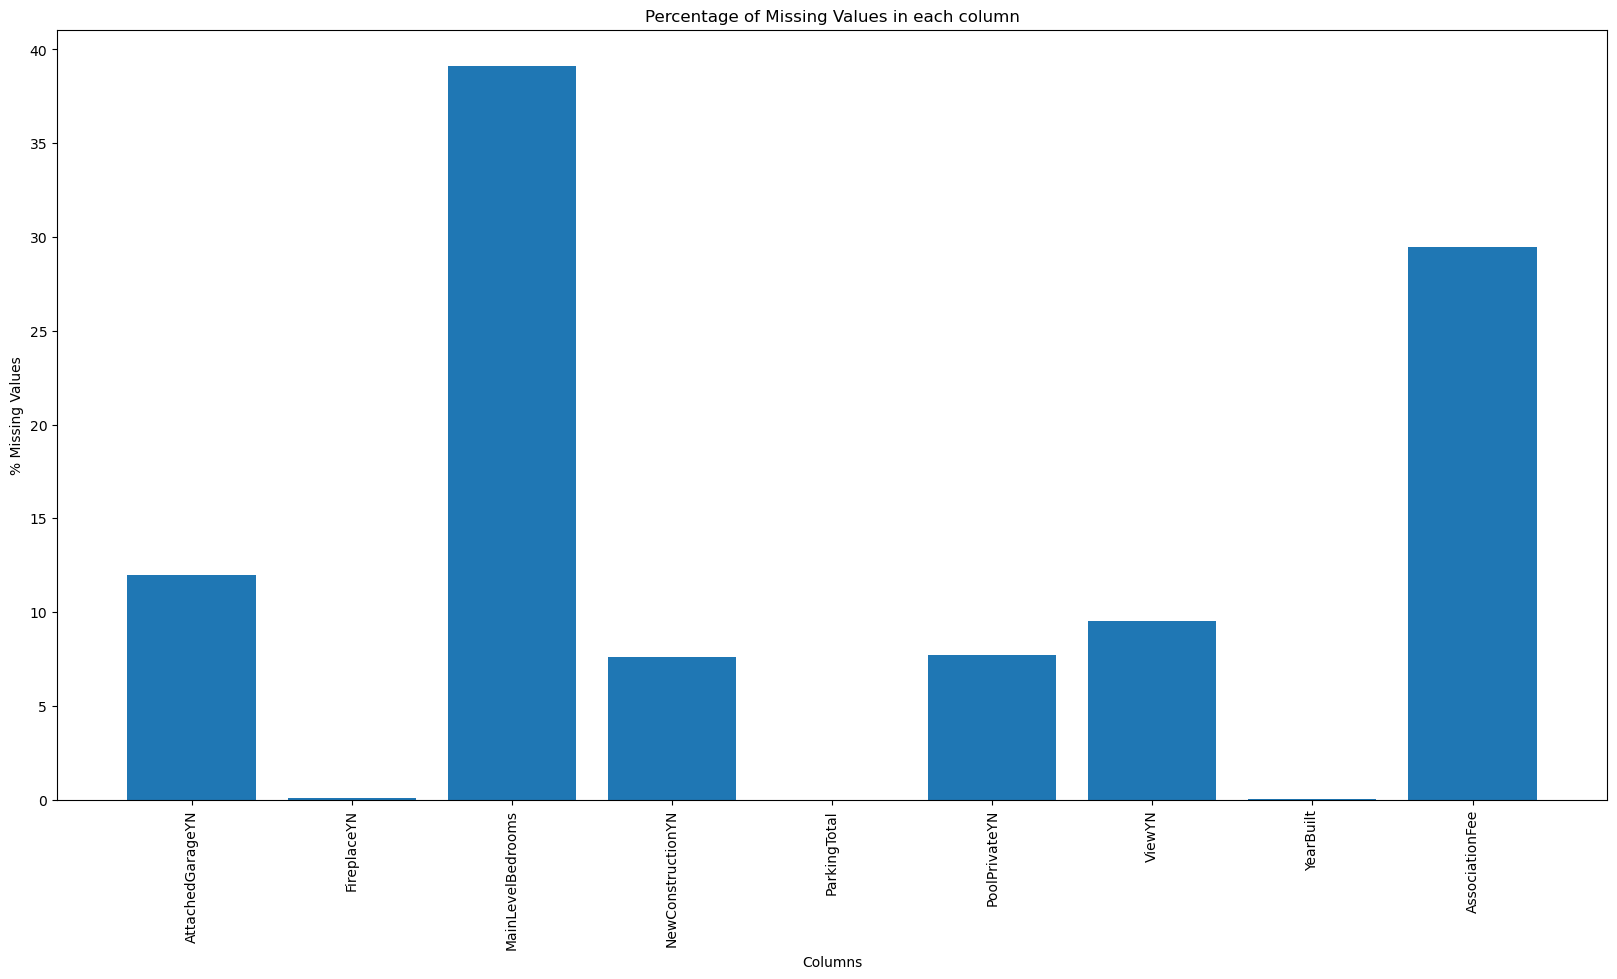

In [5]:
def column_na_plot(df: pd.DataFrame):
    is_na = []
    data = df.copy()
    for column in data.columns:
        is_na_perc = data[column].isna().sum() * 100 / len(data[column])
        if is_na_perc > 0:
            is_na.append( is_na_perc )
        else:
            data.drop(column, axis=1, inplace=True)
    plt.figure(figsize = (20,10))
    plt.bar(x=data.columns, height=is_na)
    plt.xticks(rotation=90)
    plt.xlabel('Columns')
    plt.ylabel('% Missing Values')
    plt.title('Percentage of Missing Values in each column')
    plt.show()
column_na_plot(X_train)


### Assume values for missing value of YN columns are N

# ======================
# Evaluation Section
# ======================


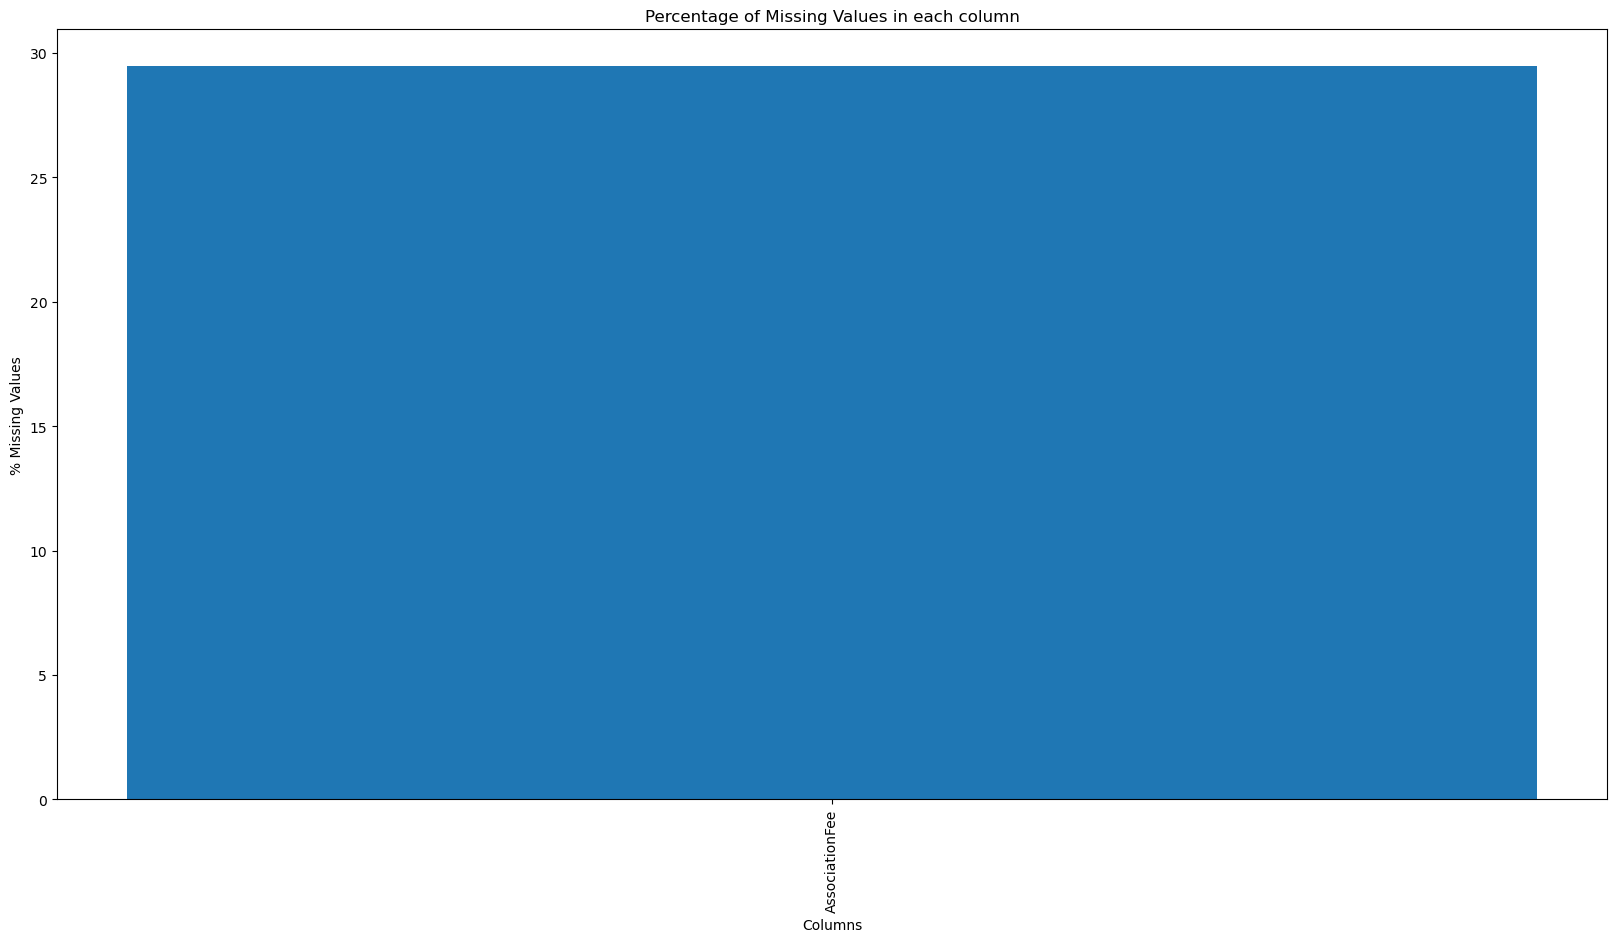

In [6]:
imputer = SimpleImputer(strategy="most_frequent")
cols_to_impute = ['AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN', 'PoolPrivateYN', 'ViewYN', 'ParkingTotal', 'YearBuilt', 'MainLevelBedrooms']
X_train[cols_to_impute] = imputer.fit_transform(X_train[cols_to_impute])
X_test[cols_to_impute] = imputer.fit_transform(X_test[cols_to_impute])
column_na_plot(X_train)


## Assume houses with missing HOA are houses with no HOA

In [7]:
def fill_zeros(x):
    if pd.isna(x):
        return 0
    else:
        return x

X_train['AssociationFee'] = X_train['AssociationFee'].apply(fill_zeros)
X_test['AssociationFee'] = X_test['AssociationFee'].apply(fill_zeros)

In [8]:
cols_with_na = []
for col in X_train.columns:
    na_count = X_train[col].isna().sum()
    print(f'{col}: {na_count} NAs')
    if na_count < 100:
        cols_with_na.append(col)

Latitude: 0 NAs
Longitude: 0 NAs
PostalCode: 0 NAs
AttachedGarageYN: 0 NAs
BathroomsTotalInteger: 0 NAs
BedroomsTotal: 0 NAs
FireplaceYN: 0 NAs
GarageSpaces: 0 NAs
LivingArea: 0 NAs
MainLevelBedrooms: 0 NAs
NewConstructionYN: 0 NAs
ParkingTotal: 0 NAs
PoolPrivateYN: 0 NAs
Stories: 0 NAs
ViewYN: 0 NAs
YearBuilt: 0 NAs
LotSizeAcres: 0 NAs
LotSizeArea: 0 NAs
LotSizeSquareFeet: 0 NAs
AssociationFee: 0 NAs
DaysOnMarket: 0 NAs
sin_closed_date: 0 NAs
Flooring_SeeRemarks: 0 NAs
Flooring_Tile: 0 NAs
Flooring_Stone: 0 NAs
Flooring_Vinyl: 0 NAs
Flooring_Bamboo: 0 NAs
Flooring_Brick: 0 NAs
Flooring_Carpet: 0 NAs
Flooring_Wood: 0 NAs
Flooring_Laminate: 0 NAs
Flooring_Concrete: 0 NAs
Levels_Two: 0 NAs
Levels_One: 0 NAs
Levels_MultiSplit: 0 NAs
Levels_ThreeOrMore: 0 NAs


# Eval with Random Forest

In [9]:
from sklearn.model_selection import train_test_split
rf = RandomForestRegressor(n_estimators=100, max_depth=20)
result = rf.fit(X=X_train, y=y_train)
result


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [14]:
y_pred = rf.predict(X_test)
from sklearn.metrics import r2_score, make_scorer
from sklearn.model_selection import cross_validate
def mdape(y_pred, y_test):
    error = abs(y_test - y_pred)
    return np.median((error * 100) / y_test)
mdape_score = make_scorer(mdape, greater_is_better=False)
r2_result = cross_validate(rf, X=X_test, y=y_test, scoring=['r2', 'neg_median_absolute_error'], cv=5)
mdape_result = mdape(y_pred, y_test)
# print(f'MdAPE: {mdape_result}%')
print(f'R2: {r2_result}')


MdAPE: 0.5913310389333973%
R2: {'fit_time': array([4.37640905, 4.37325597, 4.32907009, 4.38217902, 4.25227904]), 'score_time': array([0.03671193, 0.03175712, 0.03176308, 0.03226209, 0.03058887]), 'test_r2': array([0.80698431, 0.84153681, 0.84973397, 0.85171412, 0.79432904]), 'test_neg_median_absolute_error': array([-0.10988931, -0.09386972, -0.09600795, -0.09670434, -0.11147099])}


In [15]:
def real_world_mdape(y_pred_log, y_test_log):
    # Convert back to original scale (e.g., Dollars)
    y_pred_actual = np.exp(y_pred_log)
    y_test_actual = np.exp(y_test_log)

    # Calculate percentage error on the actual values
    error = np.abs(y_test_actual - y_pred_actual)
    return np.median(error / y_test_actual) * 100

# Run this on your results
actual_mdape = real_world_mdape(y_pred, y_test)
print(f'Actual Price MdAPE: {actual_mdape:.2f}%')

Actual Price MdAPE: 8.09%


# The results are not good lol

Text(0.5, 0, 'residual')

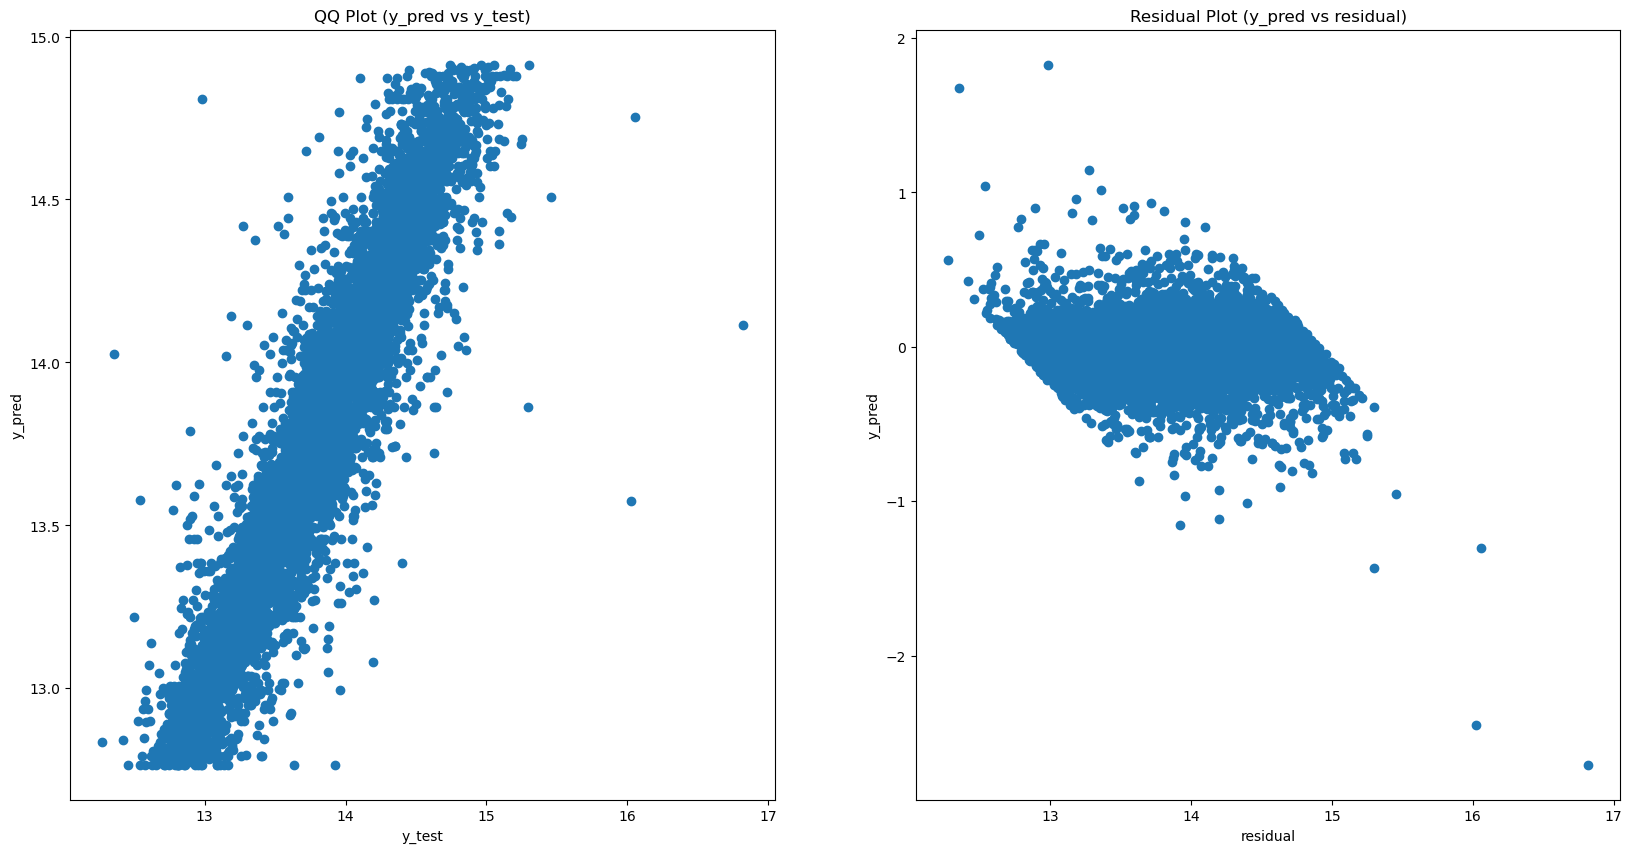

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,10))

axs[0].scatter(x=y_pred, y=y_test)
axs[0].set_title("QQ Plot (y_pred vs y_test)")
axs[0].set_ylabel("y_pred")
axs[0].set_xlabel("y_test")


axs[1].scatter(x=y_pred, y=y_test-y_pred)
axs[1].set_title("Residual Plot (y_pred vs residual)")
axs[1].set_ylabel("y")
axs[1].set_xlabel("residual")

In [1]:
explainer = shap.TreeExplainer(rf)
shap_val = explainer.shap_values(X_test[:1000])
shap.summary_plot


ModuleNotFoundError: No module named 'shap'

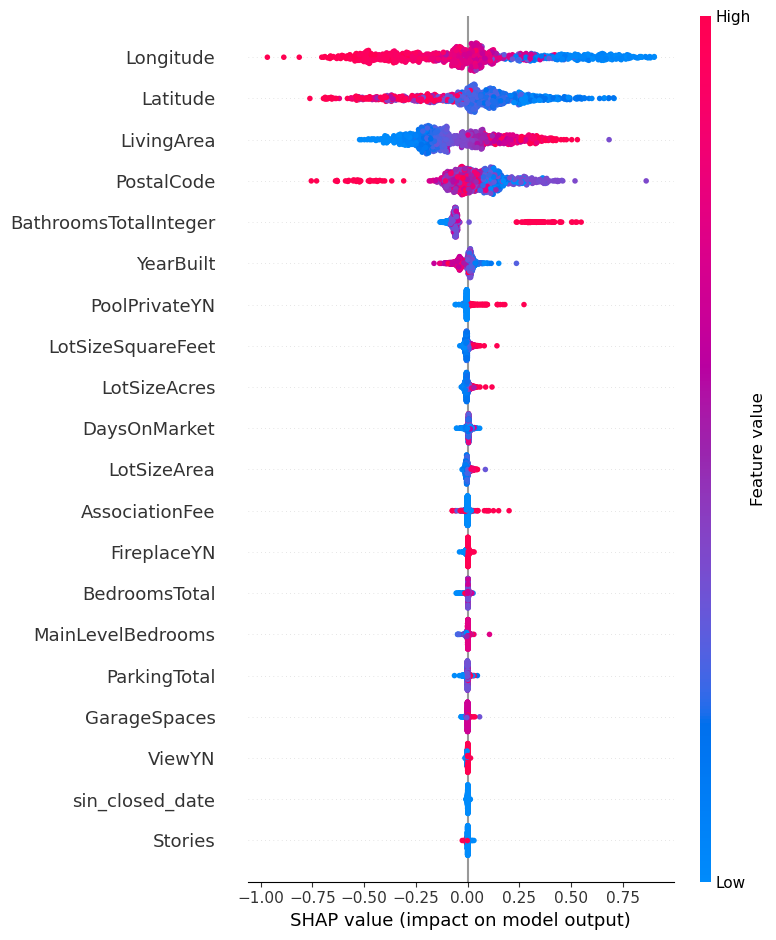

In [13]:
shap.summary_plot(shap_val, X_test[:1000])

### Geo info seems to have the most impact on log_price

In [3]:
from src.Preprocessing import get_unprocessed_data
df = get_unprocessed_data()
df['Flooring'].unique()


Retrieved 186296 rows of data from the database.


<StringArray>
[                                     nan,
                        'Carpet,Laminate',
                            'Carpet,Tile',
                       'Carpet,Tile,Wood',
                          'Laminate,Tile',
                               'Laminate',
                           'Carpet,Vinyl',
                 'Carpet,Tile,Vinyl,Wood',
                                   'Tile',
                                   'Wood',
 ...
  'Carpet,Laminate,Stone,Tile,Vinyl,Wood',
                 'Bamboo,SeeRemarks,Wood',
       'Carpet,Laminate,Stone,Vinyl,Wood',
                 'Bamboo,Tile,Vinyl,Wood',
        'Bamboo,Laminate,Stone,Tile,Wood',
           'Brick,Carpet,Stone,Tile,Wood',
  'Carpet,Laminate,SeeRemarks,Stone,Tile',
 'Concrete,Laminate,SeeRemarks,Tile,Wood',
  'Carpet,Laminate,SeeRemarks,Stone,Wood',
         'Concrete,SeeRemarks,Tile,Vinyl']
Length: 283, dtype: str

In [1]:
X_train, X_test, y_train, y_test = get_preprocessed_data(output_as='random_split')


Creating database directory...
Data folders created.
Database file found. Initializing connection...
No new CSVs to import to the database. Returning connection...
Connection initialized.
Retrieved 186296 rows of data from the database.
Processing 186296 rows of data.
Finished parsing PostalCode.
Finished cyclical encoding CloseDate.
Finished transforming abs(DaysOnMarket).
Finished transforming log(ClosePrice).
Finished transforming log(lastPriceByZip).
Found pre-trained encoder model for Flooring. Returning artifact...
Encoding Flooring...
Encoded Flooring with MultiLabelBinarizer.
Finished de-stacking and encoding Flooring.
Found pre-trained encoder model for Levels. Returning artifact...
Encoding Levels...
Encoded Levels with MultiLabelBinarizer.
Finished de-stacking and encoding Levels.
Finished feature engineering.
Found pre-trained imputer model for YearBuilt. Returning artifact...
Finished imputation for YearBuilt.
Found pre-trained imputer model for BedroomsTotal. Returning ar

In [5]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 149022 entries, 174346 to 121958
Data columns (total 38 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Latitude               149022 non-null  float64       
 1   Longitude              149022 non-null  float64       
 2   PostalCode             149022 non-null  float64       
 3   AttachedGarageYN       149022 non-null  float64       
 4   BathroomsTotalInteger  149022 non-null  float64       
 5   BedroomsTotal          149022 non-null  float64       
 6   FireplaceYN            149022 non-null  float64       
 7   GarageSpaces           149022 non-null  float64       
 8   LivingArea             149022 non-null  float64       
 9   MainLevelBedrooms      149022 non-null  float64       
 10  NewConstructionYN      149022 non-null  float64       
 11  ParkingTotal           149022 non-null  float64       
 12  PoolPrivateYN          149022 non-null  float64       


In [6]:
X_train.drop("ReadDate", axis=1, inplace=True)
X_test.drop("ReadDate", axis=1, inplace=True)

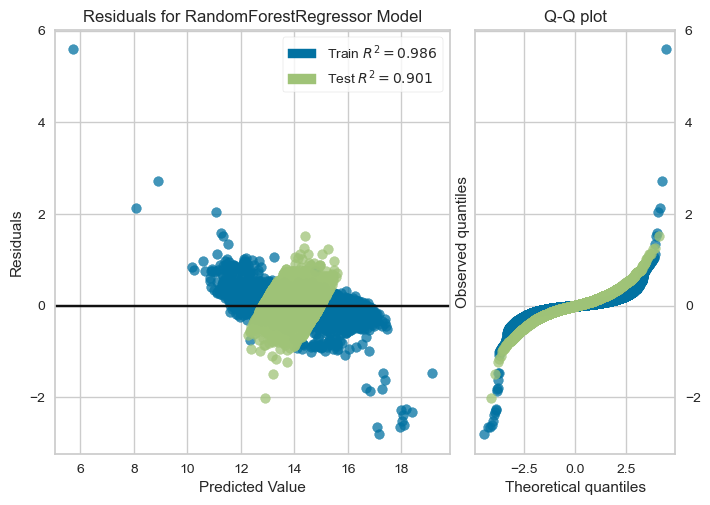

<Axes: title={'center': 'Residuals for RandomForestRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [7]:
from yellowbrick.regressor import ResidualsPlot
# Huiyu's best RF model from GridSearchCV
rf = RandomForestRegressor(n_estimators=200, min_samples_split=2, min_samples_leaf=1, max_features='sqrt')
visualizer = ResidualsPlot(rf, qqplot=True, hist=False)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()


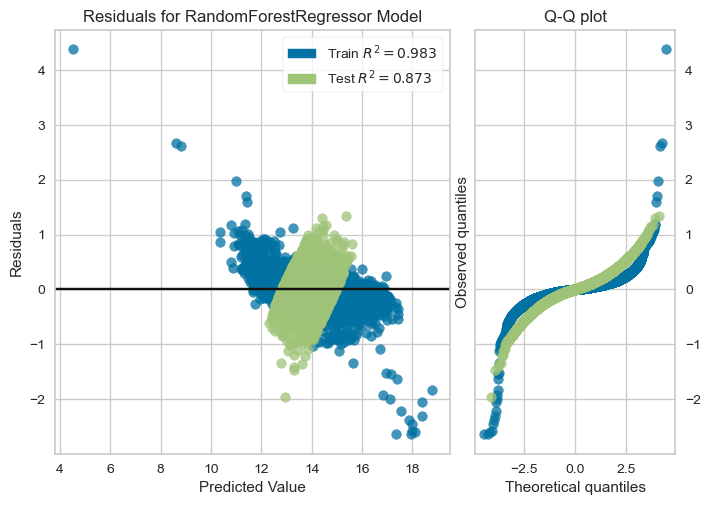

<Axes: title={'center': 'Residuals for RandomForestRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [2]:
# Huiyu's best RF model from GridSearchCV
rf = RandomForestRegressor(n_estimators=200, min_samples_split=2, min_samples_leaf=1, max_features='sqrt')
visualizer = ResidualsPlot(rf, qqplot=True, hist=False)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()


# Model Evaluation using metrics (Training set)

In [9]:
from validation import evaluate
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
evaluate(y_pred=y_pred, y_test=y_test)


R2: 0.8581
R2 (log): 0.9007
MdAPE (log-scale): 0.57%
MdAPE (dollar-scale): 7.76%


C:\Users\Eddie Nguyen\.conda\envs\IDX\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


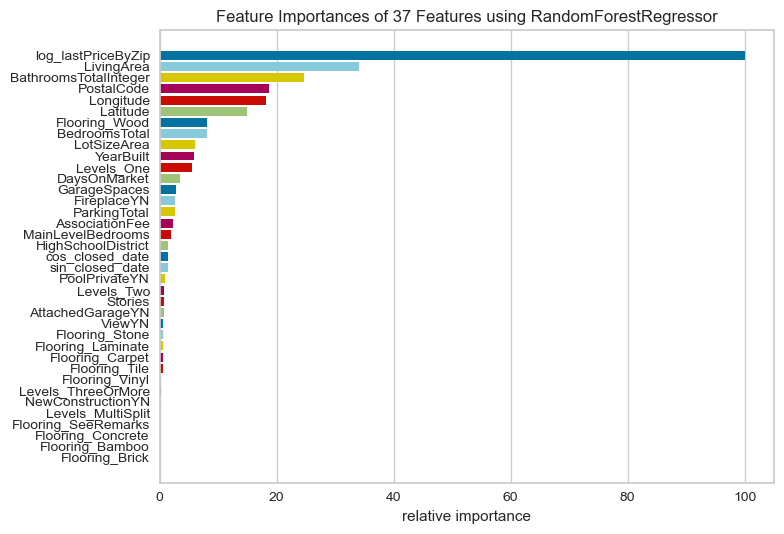

<Axes: title={'center': 'Feature Importances of 37 Features using RandomForestRegressor'}, xlabel='relative importance'>

In [8]:
from yellowbrick.model_selection import FeatureImportances
visualizer = FeatureImportances(rf)
visualizer.fit(X_train, y_train)
visualizer.show()


C:\Users\Eddie Nguyen\.conda\envs\IDX\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


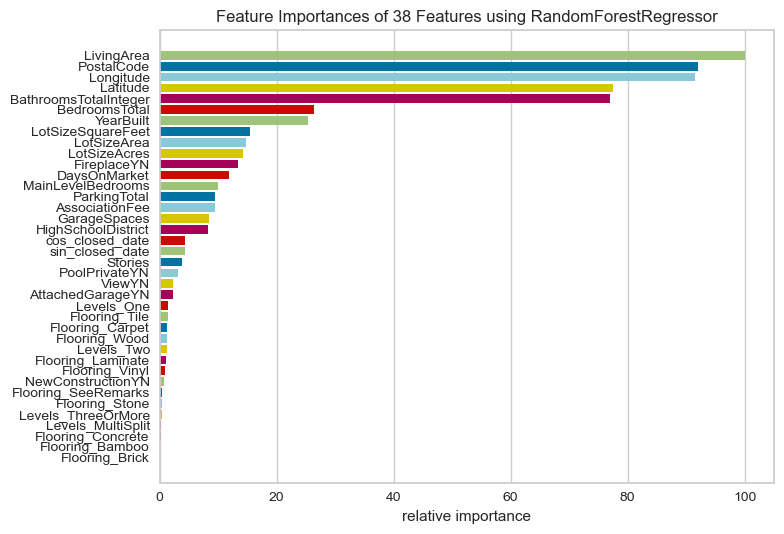

<Axes: title={'center': 'Feature Importances of 38 Features using RandomForestRegressor'}, xlabel='relative importance'>

In [5]:
from sklearn.preprocessing import TargetEncoder
encoder = TargetEncoder(smooth='auto', cv=5)
X_train['PostalCode'] = encoder.fit_transform(X_train[['PostalCode']], y_train)
X_test['PostalCode'] = encoder.fit_transform(X_test[['PostalCode']], y_test)
visualizer = FeatureImportances(rf)
visualizer.fit(X_train, y_train)
visualizer.show()


C:\Users\Eddie Nguyen\.conda\envs\IDX\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


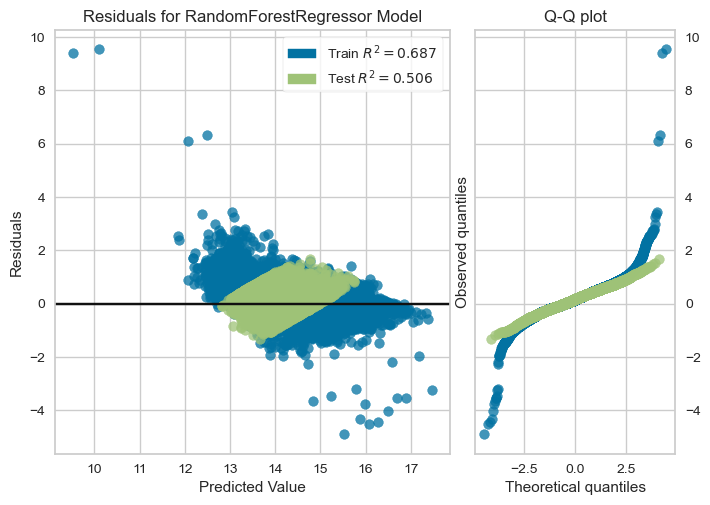

<Axes: title={'center': 'Residuals for RandomForestRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [27]:
visualizer = ResidualsPlot(rf, qqplot=True, hist=False)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

# Model Evaluation (Evaluation set Jan 26)


In [10]:
from Preprocessing import get_eval_data
eval_df = get_eval_data()
target = eval_df['log_price']
eval_df.drop(columns=['log_price'], inplace=True)


Creating database directory...
Data folders created.
Database file found. Initializing connection...
No new CSVs to import to the database. Returning connection...
Connection initialized.
Retrieved 8542 rows of data from the database.
Processing 8542 rows of data.
Finished parsing PostalCode.
Finished cyclical encoding CloseDate.
Finished transforming abs(DaysOnMarket).
Finished transforming log(ClosePrice).
Finished transforming log(lastPriceByZip).
Found pre-trained encoder model for Flooring. Returning artifact...
Encoding Flooring...
Encoded Flooring with MultiLabelBinarizer.
Finished de-stacking and encoding Flooring.
Found pre-trained encoder model for Levels. Returning artifact...
Encoding Levels...
Encoded Levels with MultiLabelBinarizer.
Finished de-stacking and encoding Levels.
Finished feature engineering.
Found pre-trained imputer model for YearBuilt. Returning artifact...
Finished imputation for YearBuilt.
Found pre-trained imputer model for BedroomsTotal. Returning artifa

In [13]:
from validation import get_eval_plots, evaluate
eval_df.drop(columns=['ReadDate'], inplace=True)
y_pred = rf.predict(eval_df)
evaluate(y_pred=y_pred, y_test=target)


R2: 0.0129
R2 (log): 0.8929
MdAPE (log-scale): 0.65%
MdAPE (dollar-scale): 8.95%


C:\Users\Eddie Nguyen\AppData\Local\Temp\ipykernel_59248\3684330063.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  get_eval_plots(y_pred, target).show()


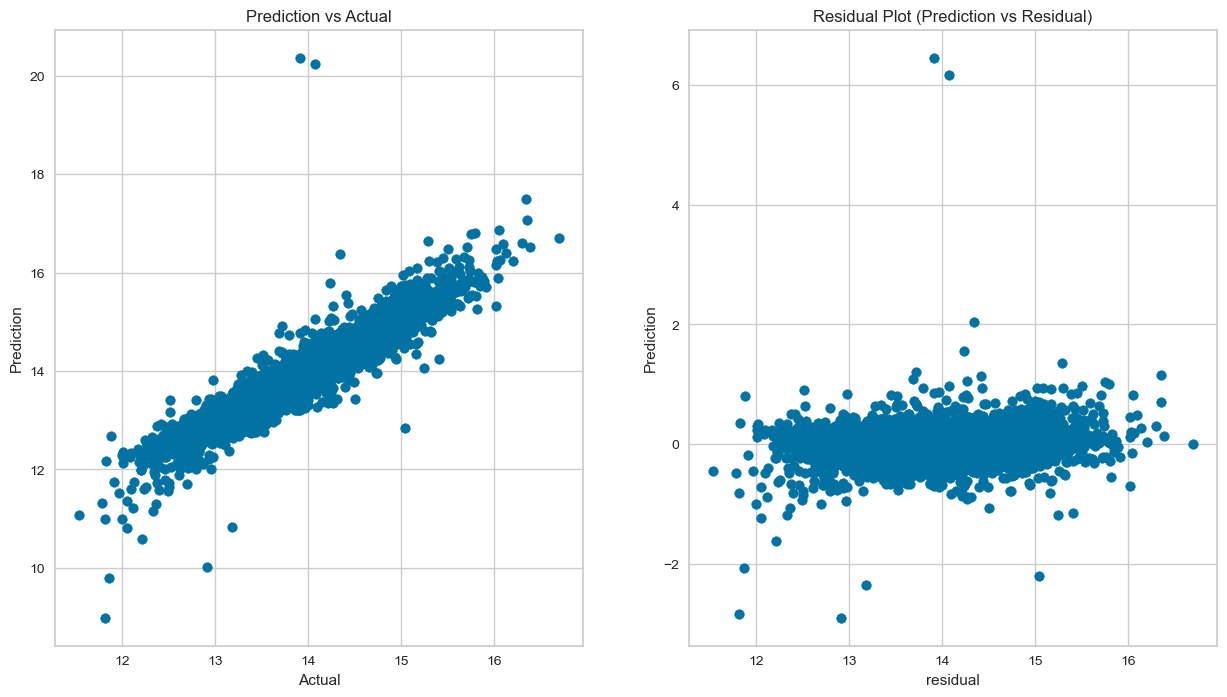

In [14]:


get_eval_plots(y_pred, target).show()

# Model Performance

## 1. Predictive Accuracy
The model demonstrates strong linear alignment across the primary target range ($12$ to $16$ on the log scale). The tight grouping in the $y_{pred}$ vs. $y_{test}$ plot indicates that the current feature engineering has successfully captured the underlying signal of the dataset.
## 2. Residual Analysis
### Central Tendency:
The majority of residuals are centered around zero with constant variance (homoscedasticity) within the "trust zone," suggesting the model is unbiased for the bulk of the data.
### Outlier Detection:
Two significant outliers were identified with high positive residuals. These represent extreme cases where the model significantly under-predicted the target. These can be addressed via input clipping or robust filtering during the preprocessing stage.

In [15]:
X_train.columns

Index(['Latitude', 'Longitude', 'PostalCode', 'AttachedGarageYN',
       'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'GarageSpaces',
       'LivingArea', 'MainLevelBedrooms', 'NewConstructionYN', 'ParkingTotal',
       'PoolPrivateYN', 'Stories', 'ViewYN', 'YearBuilt', 'HighSchoolDistrict',
       'LotSizeAcres', 'LotSizeArea', 'LotSizeSquareFeet', 'AssociationFee',
       'DaysOnMarket', 'sin_closed_date', 'cos_closed_date', 'Flooring_Bamboo',
       'Flooring_Brick', 'Flooring_Carpet', 'Flooring_Concrete',
       'Flooring_Laminate', 'Flooring_SeeRemarks', 'Flooring_Stone',
       'Flooring_Tile', 'Flooring_Vinyl', 'Flooring_Wood', 'Levels_MultiSplit',
       'Levels_One', 'Levels_ThreeOrMore', 'Levels_Two'],
      dtype='str')

In [1]:
from Preprocessing import get_preprocessed_data
df = get_preprocessed_data(output_as='df')


Creating database directory...
Data folders created.
Database file found. Initializing connection...
No new CSVs to import to the database. Returning connection...
Connection initialized.
Retrieved 186296 rows of data from the database.
Processing 186296 rows of data.
Finished parsing PostalCode.
Finished cyclical encoding CloseDate.
Finished transforming abs(DaysOnMarket).
Finished transforming log(ClosePrice).
Found pre-trained encoder model for Flooring. Returning artifact...
Encoding Flooring...
Encoded Flooring with MultiLabelBinarizer.
Finished de-stacking and encoding Flooring.
Found pre-trained encoder model for Levels. Returning artifact...
Encoding Levels...
Encoded Levels with MultiLabelBinarizer.
Finished de-stacking and encoding Levels.
Finished feature engineering.
Found pre-trained imputer model for YearBuilt. Returning artifact...
Finished imputation for YearBuilt.
Found pre-trained imputer model for BedroomsTotal. Returning artifact...
Finished imputation for BedroomsT

In [32]:
postal_code_agg = df.groupby(['PostalCode', 'ReadDate'])['log_price'].mean()
# original_agg.sort_values(['PostalCode', 'ReadDate'], inplace=True, ascending=False)
for zipcode in df.PostalCode.unique():
    postal_code_agg[zipcode] = postal_code_agg[zipcode].shift(1, fill_value=0)

postal_code_agg = postal_code_agg.reset_index()
postal_code_agg.rename(columns={"log_price": "lastPriceByZip"}, inplace=True)

In [33]:
pd.merge(df, postal_code_agg, how='left', on=['PostalCode', 'ReadDate'])

,Latitude,Longitude,PostalCode,AttachedGarageYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,GarageSpaces,LivingArea,MainLevelBedrooms,...,Flooring_SeeRemarks,Flooring_Stone,Flooring_Tile,Flooring_Vinyl,Flooring_Wood,Levels_MultiSplit,Levels_One,Levels_ThreeOrMore,Levels_Two,lastPriceByZip
0,37.439456,-122.233180,94062.0,0.0,6.0,4.0,1.0,2.0,4636.0,3.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,14.706186
1,37.878010,-121.868460,94517.0,1.0,1.0,2.0,0.0,0.0,1600.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.773810
2,34.083995,-118.066006,91770.0,0.0,1.0,2.0,1.0,2.0,937.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.715053
3,34.275406,-118.415425,91331.0,1.0,1.0,3.0,0.0,2.0,1267.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.457325
4,33.700868,-117.978506,92708.0,1.0,4.0,4.0,0.0,2.0,1920.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,14.197873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186273,33.657426,-117.999922,92648.0,0.0,1.0,1.0,0.0,0.0,600.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,14.591342
186274,39.921866,-122.183747,96021.0,0.0,2.0,3.0,0.0,0.0,1825.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.704579
186275,33.941069,-116.976432,92223.0,0.0,1.0,2.0,0.0,0.0,876.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.177191
186276,33.305878,-117.190820,92003.0,1.0,5.0,3.0,0.0,4.0,7865.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,14.326399
